In [1]:
# =========================================================
#IMPORTS
# =========================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score
from xgboost import XGBClassifier

In [2]:
# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(r"HR_Analytics.csv")
df

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0


In [3]:
# =========================================================
# BASIC CLEANING
# =========================================================
df["YearsWithCurrManager"] = df["YearsWithCurrManager"].fillna(df["YearsWithCurrManager"].median())
df = df.fillna(df.median(numeric_only=True))

# Drop useless columns
DROP_COLS = [
    "EmpID","EmployeeNumber","EmployeeCount","Over18","StandardHours","Attrition"
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

In [4]:
# =========================================================
# PEARSON CORRELATION
# =========================================================
# Select required columns
cols = [
    "JobInvolvement",
    "WorkLifeBalance",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "PerformanceRating",
    "PercentSalaryHike",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "TotalWorkingYears",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

# Subset dataframe
corr_df = df[cols]

# Pearson correlation
pearson_corr = corr_df.corr(method="pearson")

print(pearson_corr)

                         JobInvolvement  WorkLifeBalance  \
JobInvolvement                 1.000000        -0.008954   
WorkLifeBalance               -0.008954         1.000000   
EnvironmentSatisfaction       -0.013254         0.024867   
JobSatisfaction               -0.018036        -0.017625   
PerformanceRating             -0.025382         0.003438   
PercentSalaryHike             -0.014514        -0.001991   
TrainingTimesLastYear         -0.018256         0.027813   
YearsAtCompany                -0.022974         0.009902   
YearsInCurrentRole             0.005862         0.047563   
TotalWorkingYears             -0.007114         0.000091   
YearsSinceLastPromotion       -0.025929         0.007896   
YearsWithCurrManager           0.035836        -0.002313   

                         EnvironmentSatisfaction  JobSatisfaction  \
JobInvolvement                         -0.013254        -0.018036   
WorkLifeBalance                         0.024867        -0.017625   
EnvironmentS

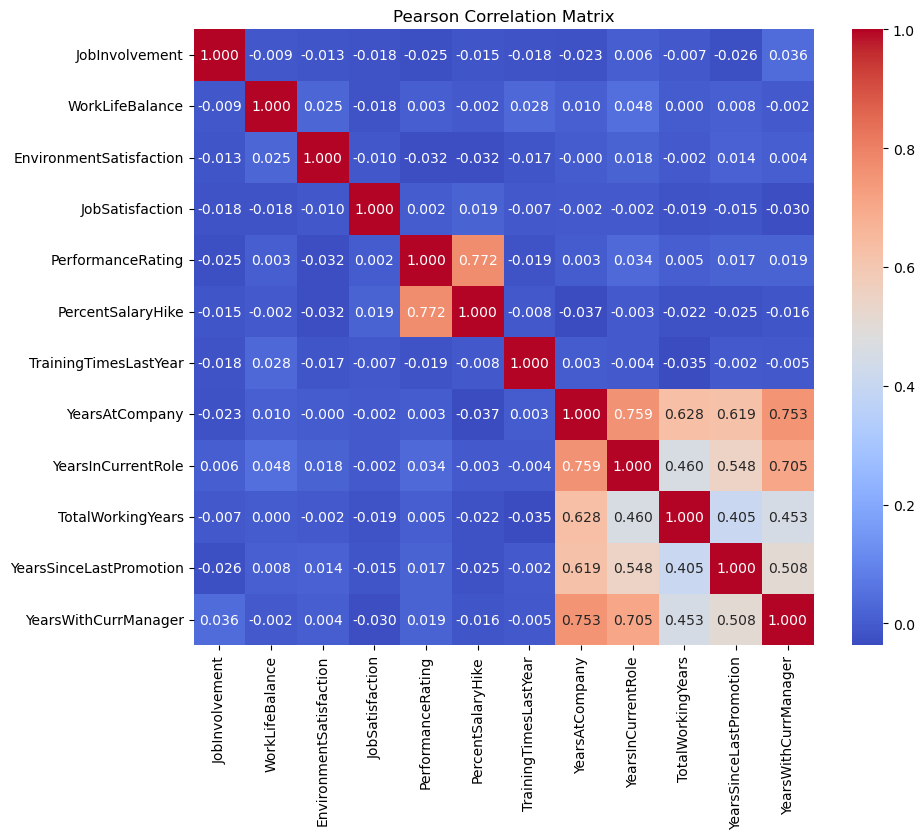

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Pearson Correlation Matrix")
plt.show()

In [6]:
# =========================================================
# DEFINE PRODUCTIVITY (CLUSTER SIGNALS)
# =========================================================
productivity_signals = [
     "JobInvolvement",
    "WorkLifeBalance",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "PerformanceRating",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "TotalWorkingYears",
]

# Scale only signals
signal_scaler = StandardScaler()
signal_scaled = signal_scaler.fit_transform(df[productivity_signals])

In [7]:
# =========================================================
# CLUSTERING → PRODUCTIVITY CLASS
# =========================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(signal_scaled)

# Map cluster → Low/Medium/High
cluster_means = df.groupby("Cluster")[productivity_signals].mean().mean(axis=1).sort_values()

cluster_map = {
    cluster_means.index[0]: "Low",
    cluster_means.index[1]: "Medium",
    cluster_means.index[2]: "High"
}

df["Productivity_Class"] = df["Cluster"].map(cluster_map)

print("\nProductivity distribution:")
print(df["Productivity_Class"].value_counts())


Productivity distribution:
Productivity_Class
Low       862
High      405
Medium    213
Name: count, dtype: int64


In [8]:
# =========================================================
# MODEL INPUT FEATURES (NO LEAKAGE)
# =========================================================
INPUT_FEATURES = [
    "Age",
    "MonthlyIncome",
    "DailyRate",
    "HourlyRate",
    "MonthlyRate",
    "JobLevel",
    "JobRole",
    "YearsWithCurrManager",
    "PercentSalaryHike",
    "TrainingTimesLastYear",
    "YearsSinceLastPromotion"
]

X = df[INPUT_FEATURES]
y = df["Productivity_Class"]

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [9]:
import joblib


# Save feature columns used in training
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [10]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


In [11]:
# =========================================================
# XGBOOST MODEL (STABLE SETTINGS)
# =========================================================
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

In [12]:
# =========================================================
# CROSS VALIDATION
# =========================================================
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring="accuracy")

print("\n--- Cross Validation ---")
print("Mean Accuracy:", cv_scores.mean())
print("Std:", cv_scores.std())


--- Cross Validation ---
Mean Accuracy: 0.6378378378378378
Std: 0.11439490505442328


In [13]:
# =========================================================
# FINAL TRAIN
# =========================================================
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr


Final Accuracy: 0.8986486486486487

Recall: 0.8986486486486487

Precision: 0.8971879308835832

F1 score: 0.8960074577659324

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.74      0.80        81
         Low       0.90      0.95      0.92       172
      Medium       0.96      1.00      0.98        43

    accuracy                           0.90       296
   macro avg       0.91      0.90      0.90       296
weighted avg       0.90      0.90      0.90       296



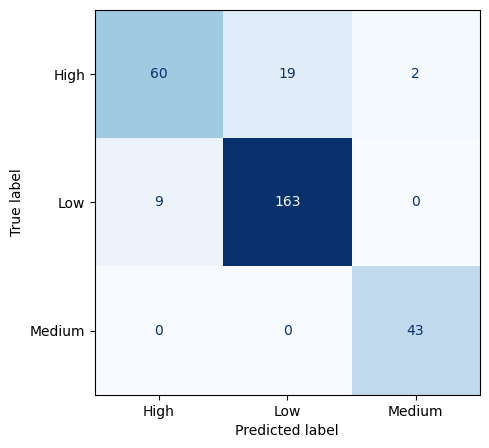

In [14]:
# =========================================================
# PREDICT
# =========================================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = model.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred, average='weighted'))
print("\nPrecision:", precision_score(y_test, y_pred, average='weighted'))
print("\nF1 score:", f1_score(y_test, y_pred, average='weighted'))

fig, ax = plt.subplots(figsize=(7,5))
disp=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred),display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False,cmap='Blues')

print("\nClassification Report:")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred)
))


In [15]:
# Convert predictions back to labels
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

In [16]:
import pandas as pd

actual_counts = pd.Series(y_test_labels).value_counts().sort_index()
pred_counts = pd.Series(y_pred_labels).value_counts().sort_index()

comparison_df = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": pred_counts
}).fillna(0)

print(comparison_df)

        Actual  Predicted
High        81         69
Low        172        182
Medium      43         45


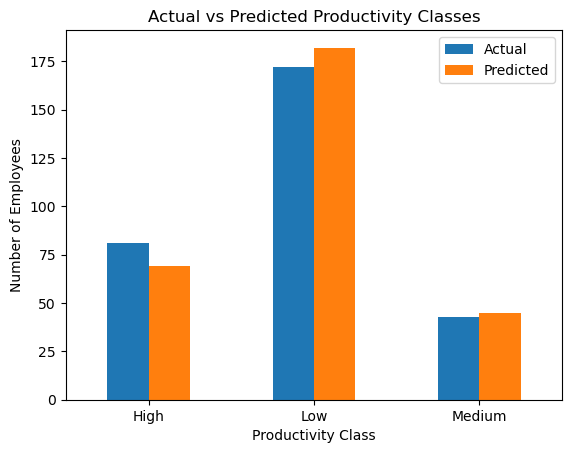

In [17]:
import matplotlib.pyplot as plt

comparison_df.plot(kind='bar')

plt.title("Actual vs Predicted Productivity Classes")
plt.ylabel("Number of Employees")
plt.xlabel("Productivity Class")
plt.xticks(rotation=0)

plt.show()

In [18]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop Important Features:")
print(importance.sort_values(ascending=False))


Top Important Features:
PercentSalaryHike                 0.266483
YearsWithCurrManager              0.167994
JobLevel                          0.114698
YearsSinceLastPromotion           0.078962
MonthlyIncome                     0.035339
JobRole_Human Resources           0.034950
JobRole_Sales Representative      0.032508
JobRole_Research Director         0.031492
JobRole_Research Scientist        0.029822
Age                               0.029560
JobRole_Laboratory Technician     0.027943
TrainingTimesLastYear             0.023452
DailyRate                         0.023011
JobRole_Manager                   0.022818
HourlyRate                        0.022467
MonthlyRate                       0.021320
JobRole_Manufacturing Director    0.021272
JobRole_Sales Executive           0.015909
dtype: float32


In [19]:
# =========================================================
# SAMPLE EMPLOYEE DATA FOR MODEL TESTING
# =========================================================
sample_employees = pd.DataFrame([

# Fresher / junior
{
    "Age": 23,
    "MonthlyIncome": 3000,
    "DailyRate": 500,
    "HourlyRate": 40,
    "MonthlyRate": 17000,
    "JobLevel": 1,
    "JobRole": "Laboratory Technician",
    "YearsWithCurrManager": 1,
    "PercentSalaryHike": 11,
    "TrainingTimesLastYear": 3,
    "YearsSinceLastPromotion": 0
},

# Average employee
{
    "Age": 29,
    "MonthlyIncome": 5500,
    "DailyRate": 850,
    "HourlyRate": 55,
    "MonthlyRate": 21000,
    "JobLevel": 2,
    "JobRole": "Research Scientist",
    "YearsWithCurrManager": 2,
    "PercentSalaryHike": 14,
    "TrainingTimesLastYear": 2,
    "YearsSinceLastPromotion": 1
},

# Stable employee
{
    "Age": 35,
    "MonthlyIncome": 9000,
    "DailyRate": 1100,
    "HourlyRate": 70,
    "MonthlyRate": 24000,
    "JobLevel": 3,
    "JobRole": "Manager",
    "YearsWithCurrManager": 4,
    "PercentSalaryHike": 16,
    "TrainingTimesLastYear": 2,
    "YearsSinceLastPromotion": 2
},

# Medium performer
{
    "Age": 33,
    "MonthlyIncome": 10000,
    "DailyRate": 1200,
    "HourlyRate": 78,
    "MonthlyRate": 26000,
    "JobLevel": 3,
    "JobRole": "Research Director",
    "YearsWithCurrManager": 3,
    "PercentSalaryHike": 20,
    "TrainingTimesLastYear": 4,
    "YearsSinceLastPromotion": 3
},

# Low growth employee
{
    "Age": 31,
    "MonthlyIncome": 4800,
    "DailyRate": 750,
    "HourlyRate": 50,
    "MonthlyRate": 19500,
    "JobLevel": 2,
    "JobRole": "Sales Executive",
    "YearsWithCurrManager": 1,
    "PercentSalaryHike": 3,
    "TrainingTimesLastYear": 1,
    "YearsSinceLastPromotion": 2
},

# Very senior employee
{
    "Age": 45,
    "MonthlyIncome": 15000,
    "DailyRate": 1400,
    "HourlyRate": 90,
    "MonthlyRate": 30000,
    "JobLevel": 4,
    "JobRole": "Manufacturing Director",
    "YearsWithCurrManager": 6,
    "PercentSalaryHike": 18,
    "TrainingTimesLastYear": 2,
    "YearsSinceLastPromotion": 2
}

])

In [27]:
sample_encoded = pd.get_dummies(sample_employees)
sample_encoded = sample_encoded.reindex(columns=X.columns, fill_value=0)

In [28]:
import shap

# # Initialize SHAP Tree Explainer
explainer = shap.TreeExplainer(model)

In [29]:
ACTIONABLE_FEATURES = [
    "PercentSalaryHike",
    "TrainingTimesLastYear",
    "YearsSinceLastPromotion",
    "MonthlyIncome",
    "YearsWithCurrManager"
]

In [30]:
# Get High productivity employees
high_class = df[df["Productivity_Class"] == "High"]

# Calculate benchmark mean
high_benchmark = high_class[ACTIONABLE_FEATURES].mean()

In [31]:

def generate_strong_recommendations(sample_input):

    shap_values = explainer(sample_input)
    results = []

    for i in range(len(sample_input)):

        pred_class = model.predict(sample_input.iloc[[i]])[0]
        pred_label = le.inverse_transform([pred_class])[0]

        class_shap_values = shap_values.values[i, :, pred_class]
        impact_series = pd.Series(
            class_shap_values,
            index=sample_input.columns
        )

        actionable_impact = impact_series[
            impact_series.index.isin(ACTIONABLE_FEATURES)
        ]

        negative_features = actionable_impact.sort_values().head(3)

        recommendations = []

        for feature in negative_features.index:

            employee_value = sample_input.iloc[i][feature]
            benchmark_value = high_benchmark[feature]

            gap = benchmark_value - employee_value

            if gap > 0:
                recommendations.append(
                    f"{feature}: Current Value = {employee_value}, "
                    f"Benchmark = {round(benchmark_value,2)}. "
                    f"An Increase by approx {round(gap,2)} may improve productivity."
                )

        results.append({
            "Employee": i,
            "Predicted_Class": pred_label,
            "Recommendations": recommendations
        })

    return results

In [32]:
results = generate_strong_recommendations(sample_encoded)

for r in results:
    print("\n==============================")
    print("Employee:", r["Employee"])
    print("Predicted Class:", r["Predicted_Class"])
    print("Recommendations:")
    for rec in r["Recommendations"]:
        print("-", rec)


Employee: 0
Predicted Class: Low
Recommendations:
- PercentSalaryHike: Current Value = 11, Benchmark = 14.13. An Increase by approx 3.13 may improve productivity.
- YearsSinceLastPromotion: Current Value = 0, Benchmark = 4.71. An Increase by approx 4.71 may improve productivity.

Employee: 1
Predicted Class: Low
Recommendations:
- MonthlyIncome: Current Value = 5500, Benchmark = 9783.75. An Increase by approx 4283.75 may improve productivity.
- TrainingTimesLastYear: Current Value = 2, Benchmark = 2.79. An Increase by approx 0.79 may improve productivity.
- YearsSinceLastPromotion: Current Value = 1, Benchmark = 4.71. An Increase by approx 3.71 may improve productivity.

Employee: 2
Predicted Class: Low
Recommendations:
- MonthlyIncome: Current Value = 9000, Benchmark = 9783.75. An Increase by approx 783.75 may improve productivity.
- TrainingTimesLastYear: Current Value = 2, Benchmark = 2.79. An Increase by approx 0.79 may improve productivity.
- YearsSinceLastPromotion: Current Valu

In [33]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(le, "encoder.pkl")

['encoder.pkl']

In [34]:
# joblib.dump(job_encoder, "jobrole_encoder.pkl")

In [35]:
joblib.dump(high_benchmark, "benchmark.pkl")

['benchmark.pkl']